# Part C2 — DreamBooth + FID/FRS Evaluation (Colab)
## EEEM068 Group 42 — Vedansh


In [1]:
# Cell 0 — Install
!pip install -q diffusers==0.29.2 transformers==4.41.2 accelerate==0.29.3 peft==0.10.0
!pip install -q bitsandbytes datasets pytorch-fid facenet-pytorch safetensors
!wget -q -O /content/train_dreambooth.py \
  https://raw.githubusercontent.com/huggingface/diffusers/v0.29.2/examples/dreambooth/train_dreambooth.py
!accelerate config default --mixed_precision fp16
print("Done!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 83.3 MB/s eta 0:00:00
accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml
Done!


In [1]:
# Cell 1 — Setup
import os, gc, json, random, shutil, subprocess
from pathlib import Path
import torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
MODEL_ID = "runwayml/stable-diffusion-v1-5"
IDENTITIES = [142, 320, 589]
SHOTS = {"1shot": 1, "5shot": 5}
BASE = Path("/content")
DATA = BASE / "data"
OUT = BASE / "outputs"
CLASS = DATA / "class_images"
OUT.mkdir(parents=True, exist_ok=True)
CLASS.mkdir(parents=True, exist_ok=True)
print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU: Tesla T4


In [2]:
# Cell 2 — Download identity images
from datasets import load_dataset

identity_ranges = {142: range(142,147), 320: range(320,325), 589: range(589,594)}

for identity, indices in identity_ranges.items():
    ref = DATA / f"identity_{identity}" / "reference"
    ref.mkdir(parents=True, exist_ok=True)
    if len(list(ref.glob("*.jpg"))) >= 5:
        print(f"ID {identity}: exists"); continue
    print(f"Downloading ID {identity}...")
    ds = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)
    n = 0
    for i, s in enumerate(ds):
        if i in indices:
            s["image"].convert("RGB").resize((256,256)).save(ref/f"ref_{n:02d}.jpg")
            n += 1
        if n >= 5: break

# Prepare instance dirs
for identity in IDENTITIES:
    ref = DATA / f"identity_{identity}" / "reference"
    refs = sorted(ref.glob("*.jpg"))
    for shot, n in SHOTS.items():
        inst = DATA / f"identity_{identity}" / f"instance_{shot}"
        inst.mkdir(parents=True, exist_ok=True)
        for f in inst.glob("*"): f.unlink()
        for r in refs[:n]: shutil.copy2(r, inst)
        print(f"  ID {identity} {shot}: {len(list(inst.glob('*')))} imgs")
print("Done!")


ID 142: exists
ID 320: exists
ID 589: exists
  ID 142 1shot: 1 imgs
  ID 142 5shot: 5 imgs
  ID 320 1shot: 1 imgs
  ID 320 5shot: 5 imgs
  ID 589 1shot: 1 imgs
  ID 589 5shot: 5 imgs
Done!


In [3]:
# Cell 3 — Train ALL 6 DreamBooth models
import time

for identity in IDENTITIES:
    for shot, n in SHOTS.items():
        inst = DATA / f"identity_{identity}" / f"instance_{shot}"
        out = OUT / f"identity_{identity}" / f"dreambooth_{shot}"
        if out.exists() and (out/"model_index.json").exists():
            print(f"ID {identity} {shot}: exists, skip"); continue
        print(f"\n=== Training ID {identity} {shot} ===")
        t0 = time.time()
        !python /content/train_dreambooth.py \
          --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
          --instance_data_dir="{inst}" \
          --class_data_dir="{CLASS}" \
          --output_dir="{out}" \
          --with_prior_preservation --prior_loss_weight=1.0 \
          --instance_prompt="a photo of sks person" \
          --class_prompt="a photo of a person" \
          --resolution=256 --train_batch_size=1 --gradient_accumulation_steps=1 \
          --learning_rate=2e-5 --lr_scheduler="constant" --lr_warmup_steps=0 \
          --max_train_steps=250 --mixed_precision="fp16" --seed=42 \
          --gradient_checkpointing --use_8bit_adam --num_class_images=200 --set_grads_to_none
        print(f"  Done in {(time.time()-t0)/60:.1f} min")
        gc.collect(); torch.cuda.empty_cache()
print("\n✅ All training complete!")



=== Training ID 142 1shot ===
2026-05-11 15:33:37.738993: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
05/11/2026 15:33:47 - INFO - __main__ - Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

{'image_encoder', 'requires_safety_checker'} was not found in config. Values will be initialized to default values.
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]{'encoder_hid_dim', 'conv_in_kernel', 'resn

In [4]:
# Cell 4 — Generate 300 images per model (delete model after to save disk)
from diffusers import StableDiffusionPipeline, UNet2DConditionModel

N_GEN = 300; BATCH = 8
prompts = ["a photo of sks person","a portrait of sks person",
    "a close-up photo of sks person","a photo of sks person smiling",
    "a professional photo of sks person","sks person looking at the camera"]

configs = [(i,s) for i in IDENTITIES for s in SHOTS]
for identity, shot in configs:
    model_path = OUT / f"identity_{identity}" / f"dreambooth_{shot}"
    gen_dir = OUT / f"identity_{identity}" / f"generated_{shot}"
    gen_dir.mkdir(parents=True, exist_ok=True)
    if len(list(gen_dir.glob("*.png"))) >= N_GEN:
        print(f"ID {identity} {shot}: done"); continue
    if not model_path.exists():
        print(f"ID {identity} {shot}: no model"); continue
    print(f"Generating ID {identity} {shot}...")
    try:
        pipe = StableDiffusionPipeline.from_pretrained(str(model_path),
            torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False).to("cuda")
    except:
        unet = UNet2DConditionModel.from_pretrained(str(model_path/"unet"), torch_dtype=torch.float16)
        pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, unet=unet,
            torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False).to("cuda")
    idx = len(list(gen_dir.glob("*.png")))
    pbar = tqdm(total=N_GEN-idx)
    while idx < N_GEN:
        n = min(BATCH, N_GEN-idx)
        gen = torch.Generator(device="cuda").manual_seed(SEED+idx)
        imgs = pipe([prompts[idx%len(prompts)]]*n, height=256, width=256,
                    num_inference_steps=30, guidance_scale=7.5, generator=gen).images
        for img in imgs:
            img.save(gen_dir/f"gen_{idx:04d}.png"); idx += 1
        pbar.update(n)
    pbar.close()
    del pipe; gc.collect(); torch.cuda.empty_cache()
    # Trim model to save disk
    for sub in ["text_encoder","tokenizer","feature_extractor","safety_checker","vae"]:
        p = model_path/sub
        if p.exists(): shutil.rmtree(p)

print("\n=== Summary ===")
for i in IDENTITIES:
    for s in SHOTS:
        d = OUT/f"identity_{i}/generated_{s}"
        print(f"  ID {i} {s}: {len(list(d.glob('*.png'))) if d.exists() else 0}")


Generating ID 142 1shot...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]


=== Summary ===
  ID 142 1shot: 300
  ID 142 5shot: 300
  ID 320 1shot: 300
  ID 320 5shot: 300
  ID 589 1shot: 300
  ID 589 5shot: 300


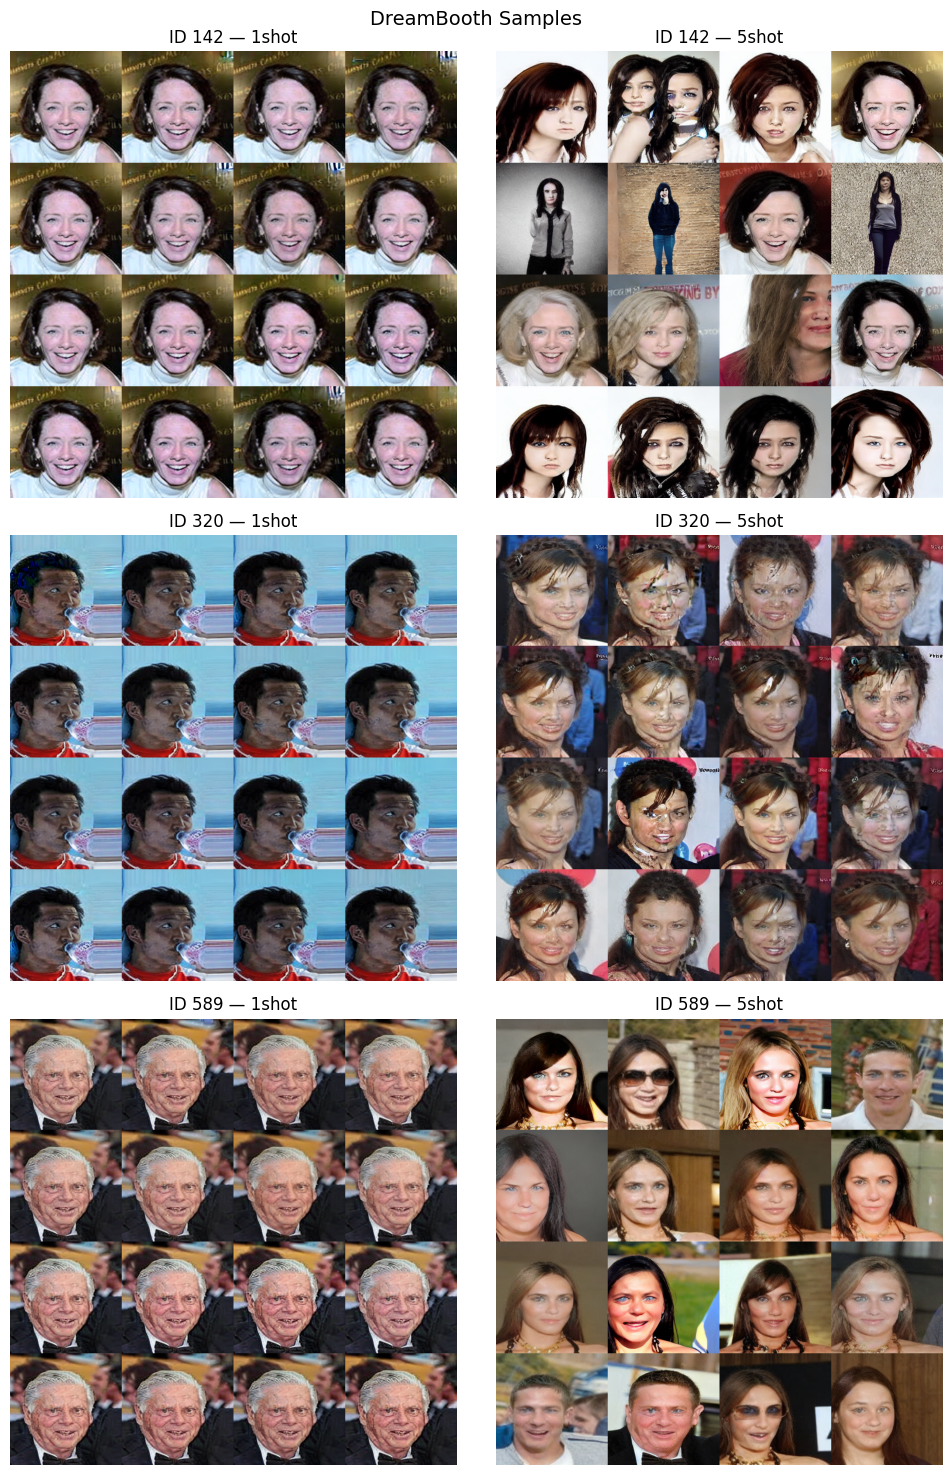

In [5]:
# Cell 5 — Sample Grids
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for row, identity in enumerate(IDENTITIES):
    for col, shot in enumerate(SHOTS):
        gen_dir = OUT/f"identity_{identity}/generated_{shot}"
        imgs = sorted(gen_dir.glob("*.png"))[:16]
        grid = Image.new("RGB", (256*4, 256*4))
        for j, p in enumerate(imgs):
            grid.paste(Image.open(p).resize((256,256)), ((j%4)*256,(j//4)*256))
        axes[row,col].imshow(grid)
        axes[row,col].set_title(f"ID {identity} — {shot}")
        axes[row,col].axis("off")
plt.suptitle("DreamBooth Samples", fontsize=14)
plt.tight_layout()
plt.savefig(OUT/"sample_grids.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
# Cell 6 — FID
from datasets import load_dataset

REAL = DATA/"real_celeba"; REAL.mkdir(exist_ok=True)
if len(list(REAL.glob("*.png"))) < 300:
    print("Downloading real images for FID...")
    ds = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)
    n = 0
    for i, s in enumerate(ds):
        if i < 1000: continue
        s["image"].convert("RGB").resize((256,256)).save(REAL/f"real_{n:04d}.png")
        n += 1
        if n >= 300: break

fid_results = {}
for identity in IDENTITIES:
    for shot in SHOTS:
        gen_dir = OUT/f"identity_{identity}/generated_{shot}"
        if not gen_dir.exists(): continue
        r = subprocess.run(["python","-m","pytorch_fid",str(REAL),str(gen_dir),
            "--batch-size","32","--device","cuda","--dims","2048"],
            capture_output=True, text=True)
        try: fid = float(r.stdout.strip().split(":")[-1].strip())
        except: fid = -1; print(f"  Parse error: {r.stdout[:200]} {r.stderr[:200]}")
        fid_results[f"{identity}_{shot}"] = fid
        print(f"FID ID{identity} {shot}: {fid:.2f}")

print("\n=== FID Results ===")
for k,v in fid_results.items(): print(f"  {k}: {v:.2f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


FID ID142 1shot: 299.73
FID ID142 5shot: 140.49
FID ID320 1shot: 323.12
FID ID320 5shot: 139.21
FID ID589 1shot: 307.05
FID ID589 5shot: 127.82

=== FID Results ===
  142_1shot: 299.73
  142_5shot: 140.49
  320_1shot: 323.12
  320_5shot: 139.21
  589_1shot: 307.05
  589_5shot: 127.82


  0%|          | 0.00/107M [00:00<?, ?B/s]

FRS ID142 1shot: mean=0.3773 std=0.0267
FRS ID142 5shot: mean=0.3096 std=0.1616
FRS ID320 1shot: mean=0.4869 std=0.0251
FRS ID320 5shot: mean=0.3481 std=0.0968
FRS ID589 1shot: mean=0.4500 std=0.0150
FRS ID589 5shot: mean=0.1494 std=0.1815


/tmp/ipykernel_10625/3150915272.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([frs_results[k] for k in labels], labels=labels)


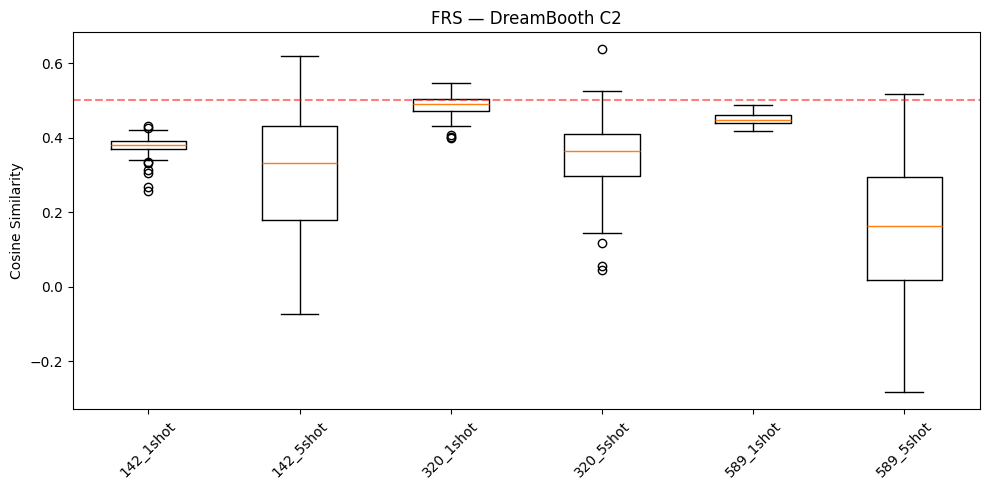

In [7]:
# Cell 7 — FRS
from facenet_pytorch import MTCNN, InceptionResnetV1

mtcnn = MTCNN(image_size=160, margin=20, device="cuda")
facenet = InceptionResnetV1(pretrained='vggface2').eval().to("cuda")

def get_emb(path):
    face = mtcnn(Image.open(path).convert("RGB"))
    if face is None: return None
    with torch.no_grad(): return facenet(face.unsqueeze(0).to("cuda")).cpu()

frs_results = {}
for identity in IDENTITIES:
    refs = sorted((DATA/f"identity_{identity}/reference").glob("*.jpg"))
    ref_embs = [e for p in refs if (e:=get_emb(p)) is not None]
    if not ref_embs: continue
    ref_mean = torch.cat(ref_embs).mean(0, keepdim=True)
    for shot in SHOTS:
        gens = sorted((OUT/f"identity_{identity}/generated_{shot}").glob("*.png"))[:100]
        sims = [torch.nn.functional.cosine_similarity(ref_mean, e).item()
                for p in gens if (e:=get_emb(p)) is not None]
        frs_results[f"{identity}_{shot}"] = sims
        print(f"FRS ID{identity} {shot}: mean={np.mean(sims):.4f} std={np.std(sims):.4f}")

# Boxplot
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(frs_results.keys())
ax.boxplot([frs_results[k] for k in labels], labels=labels)
ax.set_ylabel("Cosine Similarity"); ax.set_title("FRS — DreamBooth C2")
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(OUT/"frs_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# Cell 8 — Final Summary
print("="*60)
print("PART C2 — DreamBooth Results")
print("="*60)
print(f"{'Setting':<20} {'FID':>8} {'FRS Mean':>10} {'FRS Std':>10}")
print("-"*60)
for identity in IDENTITIES:
    for shot in SHOTS:
        k = f"{identity}_{shot}"
        fid = fid_results.get(k, -1)
        frs = frs_results.get(k, [])
        m = np.mean(frs) if frs else 0
        s = np.std(frs) if frs else 0
        print(f"ID{identity} {shot:<10} {fid:>8.2f} {m:>10.4f} {s:>10.4f}")
print("="*60)

results = {"method":"DreamBooth (HF train_dreambooth.py)","base_model":MODEL_ID,
    "hyperparams":{"resolution":256,"lr":2e-5,"steps":250,"fp16":True,"seed":42},
    "fid":{k:round(v,2) for k,v in fid_results.items()},
    "frs":{k:{"mean":round(np.mean(v),4),"std":round(np.std(v),4)} for k,v in frs_results.items()}}
with open(OUT/"partC2_results.json","w") as f: json.dump(results,f,indent=2)
print(f"\nSaved: {OUT/'partC2_results.json'}")


PART C2 — DreamBooth Results
Setting                   FID   FRS Mean    FRS Std
------------------------------------------------------------
ID142 1shot        299.73     0.3773     0.0267
ID142 5shot        140.49     0.3096     0.1616
ID320 1shot        323.12     0.4869     0.0251
ID320 5shot        139.21     0.3481     0.0968
ID589 1shot        307.05     0.4500     0.0150
ID589 5shot        127.82     0.1494     0.1815

Saved: /content/outputs/partC2_results.json
